<a href="https://colab.research.google.com/github/darrickpang/Email/blob/master/multiLinearRegressionLab_Darrick_Pang_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas import set_option
from pandas import read_csv
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from numpy import set_printoptions
import seaborn as sns
from pandas.plotting import scatter_matrix
from scipy.stats import skew
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer

# Original Data

In [ ]:
df = read_csv('boston.csv')
df.dropna()
df = df.drop(['Unnamed: 0'], axis=1)
names = df.columns
# print(names)

In [ ]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


The purpose of descriptive statistics is to provide a clear and concise summary of our data by summarizing the data and understanding the patterns, distributions, and trends. We look at
1. central tendency (mean, median, mode),
2. dispersion (min, max, variance), and
3. its shape (skewness, kurtosis).

Descriptive statistics is good for allowing researchers to communicate the key characteristics of the dataset and allow better understanding that provide the foundation for further analysis, such as whether there needs to be pre-processing or not.

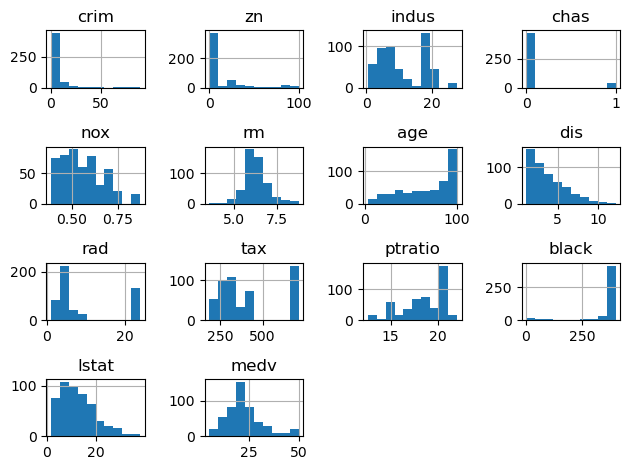

In [ ]:
df.hist()
plt.tight_layout()
plt.show()

From the histograms, we can see the roughly Gaussian distributions are
1. rm
2. medv

so standardization would be recommended on them.

However, most of them do not have a roughly Gaussian distribution. Data points such as
1. age
2. black

may need normalization because of its left-skew shape.

Histograms showing
1. nox
2. lstat
3. dis

may need a log transformation first because of its right-skew shape. A log transformation would be needed first to see what their new histograms are before we can make the decision to normalize or standardize.

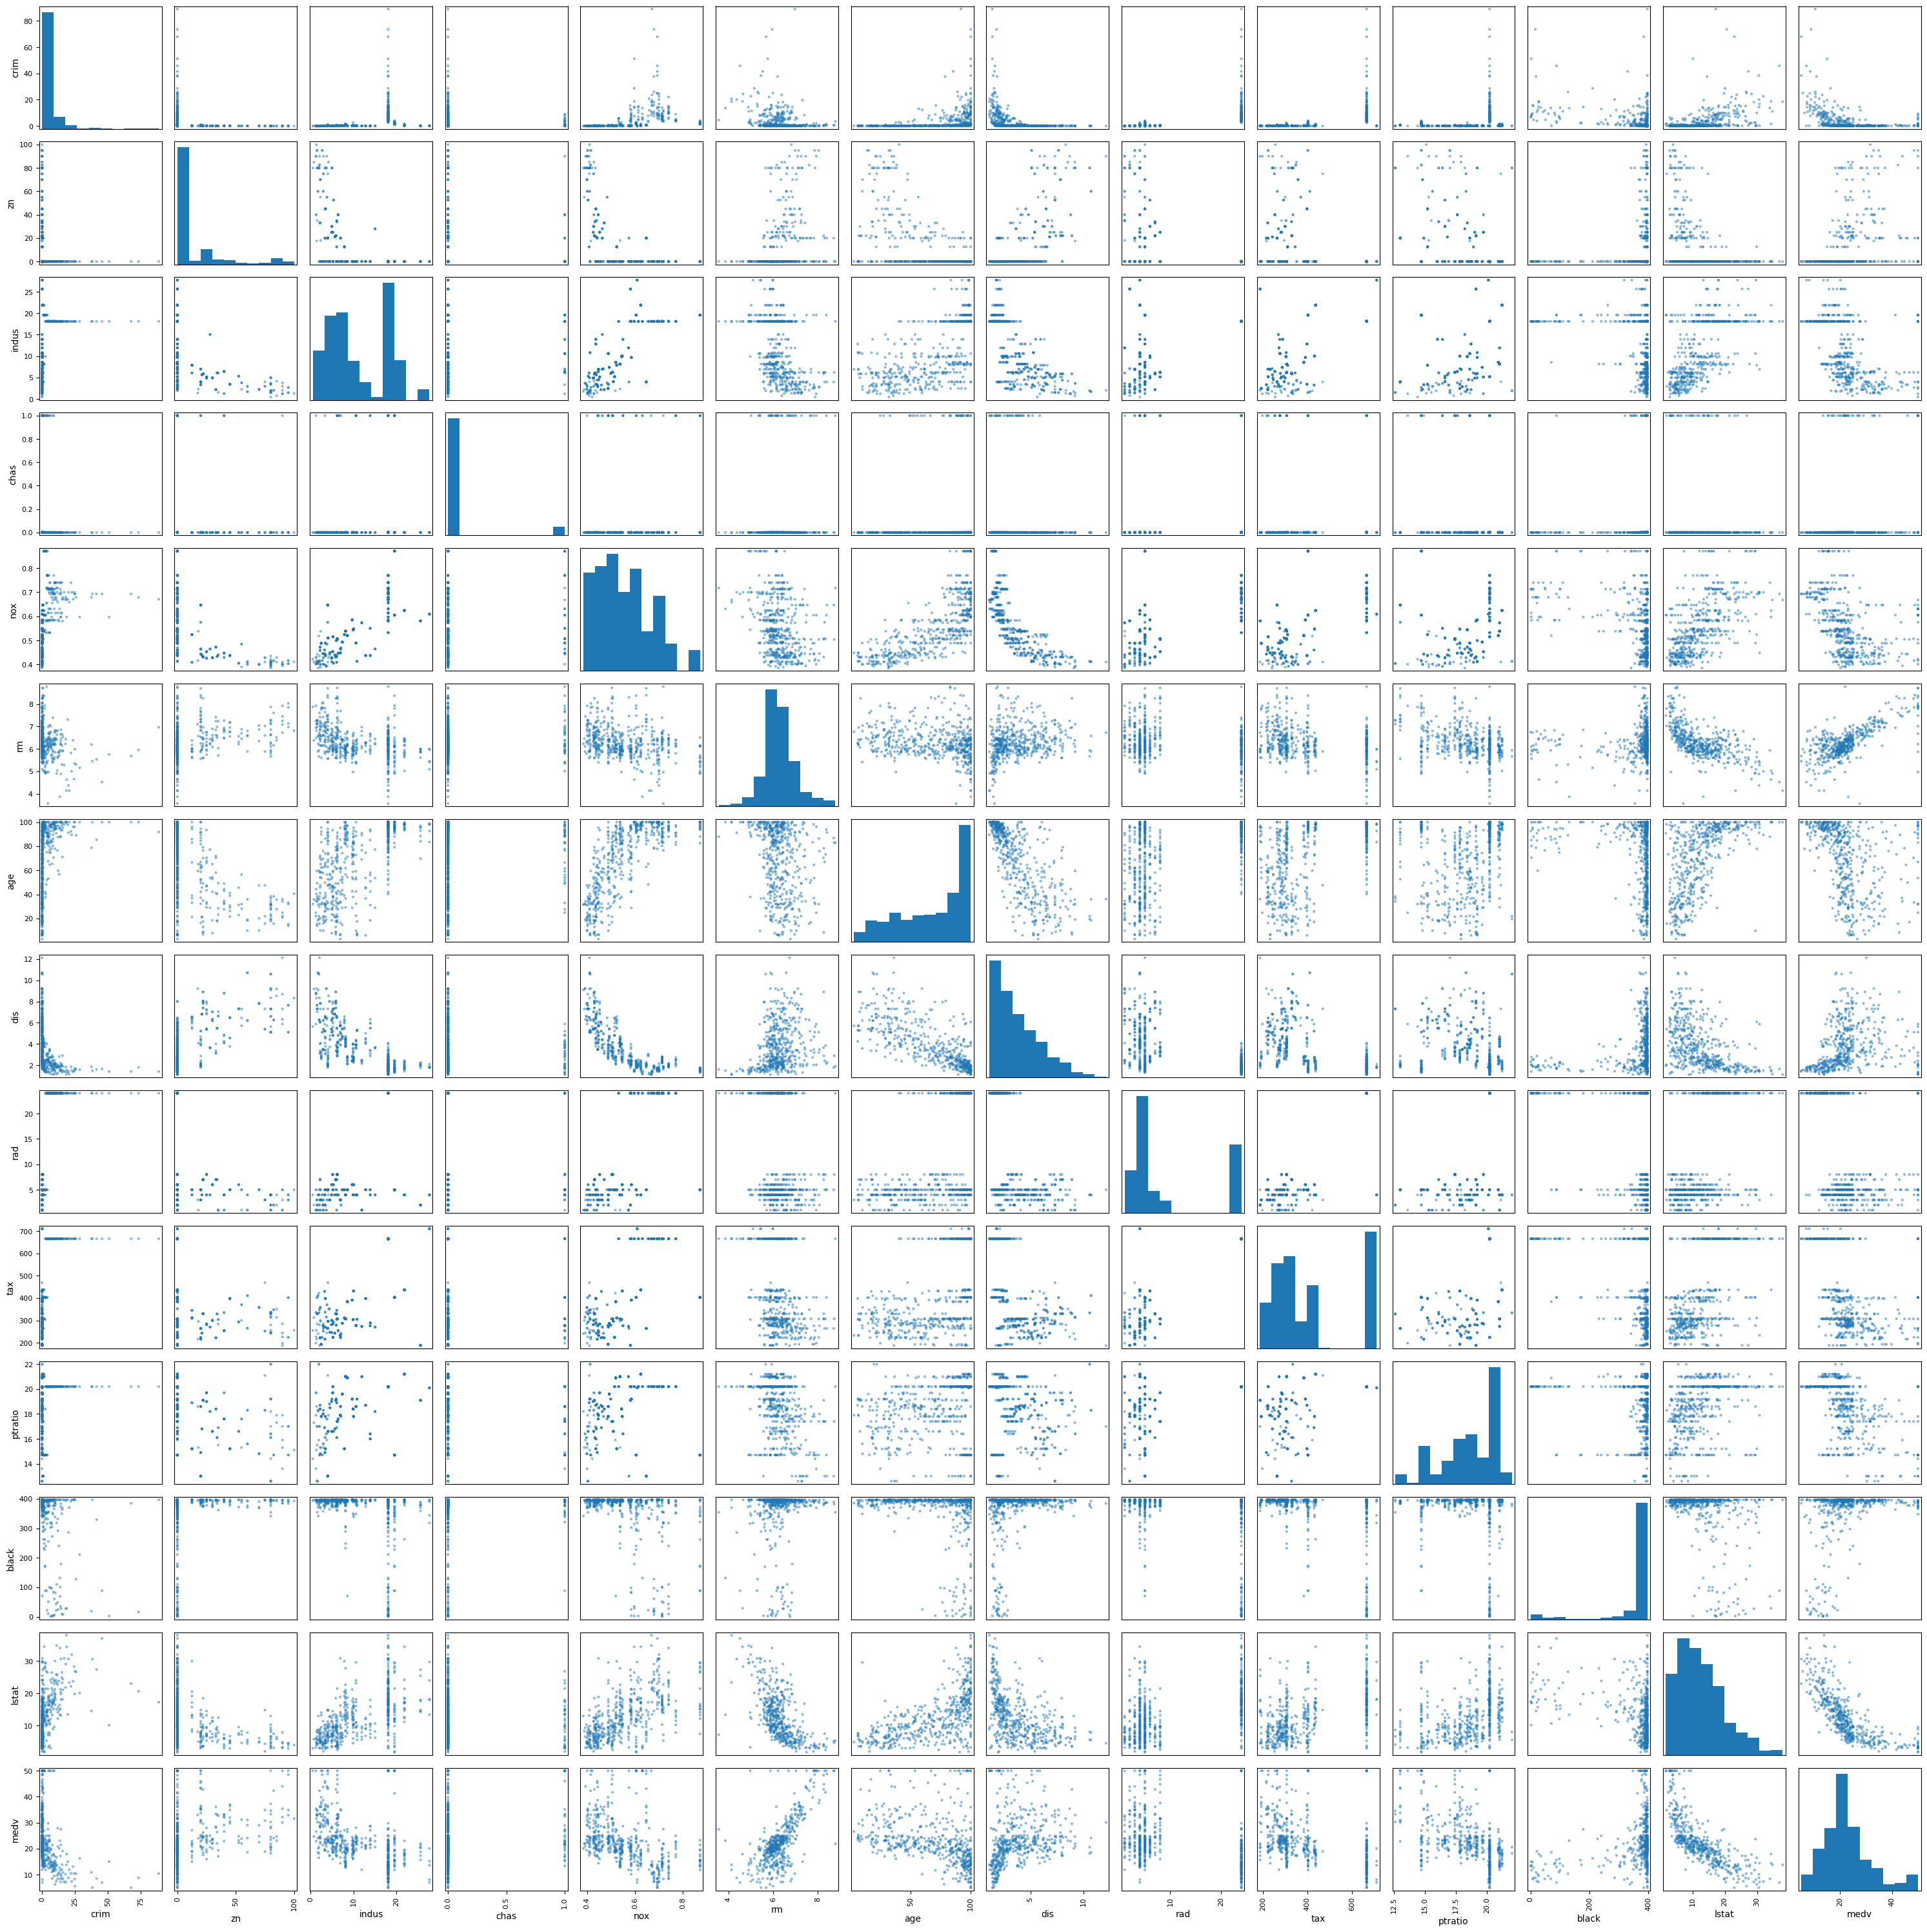

In [ ]:
scatter_matrix(df, figsize=(30, 30))
plt.tight_layout()
plt.show()

From the scatterplots, it seems

1. nox
2. rm
3. lstat
4. tax
5. ptratio

have at least a moderate correlation with the output variable medv. We will look at the correlation heatmap and see whether we are on the right track or not.

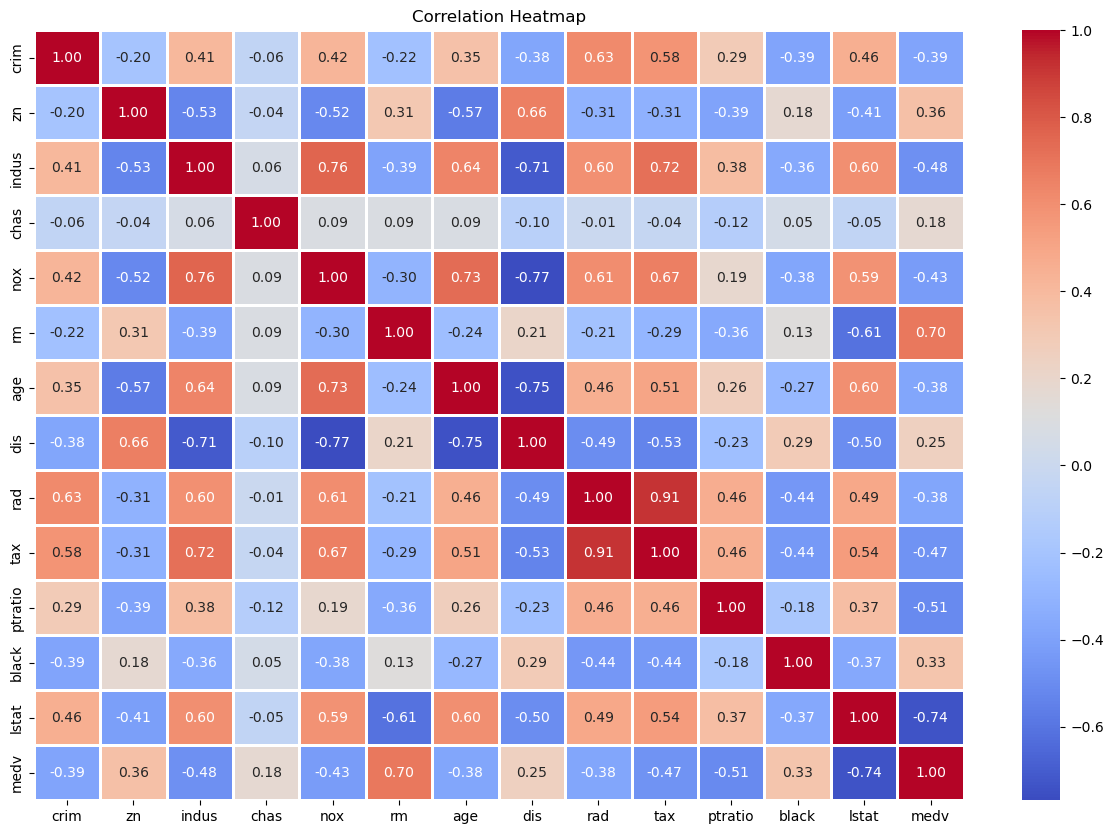

In [ ]:
plt.figure(figsize=(15, 10))

sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=2)

plt.title('Correlation Heatmap')
plt.show()

In [ ]:
correlation_matrix = df.corr()
medv_corr = correlation_matrix['medv'].sort_values(ascending=False)
print(medv_corr)

medv       1.000000
rm         0.695360
zn         0.360445
black      0.333461
dis        0.249929
chas       0.175260
age       -0.376955
rad       -0.381626
crim      -0.388305
nox       -0.427321
tax       -0.468536
indus     -0.483725
ptratio   -0.507787
lstat     -0.737663
Name: medv, dtype: float64


From the scatter plots and correlation heat map, the five input variables witht the strongest positive/negative correlation with the output variable medv are:
1. lstat (-0.74)
2. rm (0.70)
3. ptratio (-0.51)
4. indus (-0.48)
5. tax (-0.47)

We can see from just using the scatterplot,we managed to get 3 out of the 5 from the heatmap. From this alone, we can select these values when we want to use multilinear regression to predict housing values from those input values alone.

## RFE

In [ ]:
array = df.values
# print(array)
X = array[:,0:13]
Y = array[:,13]
# print(X)
# print(Y)

NUM_FEATURES = 13 # this is kind of arbitrary but the idea should come by observing the scatter plots and correlation.
model = LinearRegression()
for i in range(NUM_FEATURES, 0, -1):
    print(i)
    rfe = RFE(model, n_features_to_select=i)
    fit = rfe.fit(X, Y)
    print("Num Features:", fit.n_features_)
    print("Selected Features:", fit.support_)
    print("Feature Ranking:", fit.ranking_)
    # calculate the score for the selected features
    score = rfe.score(X,Y)
    print("Model Score with selected features is: ", score)
    print()

13
Num Features: 13
Selected Features: [ True  True  True  True  True  True  True  True  True  True  True  True
  True]
Feature Ranking: [1 1 1 1 1 1 1 1 1 1 1 1 1]
Model Score with selected features is:  0.7406426641094095

12
Num Features: 12
Selected Features: [ True  True  True  True  True  True False  True  True  True  True  True
  True]
Feature Ranking: [1 1 1 1 1 1 2 1 1 1 1 1 1]
Model Score with selected features is:  0.7406412165505145

11
Num Features: 11
Selected Features: [ True  True  True  True  True  True False  True  True  True  True False
  True]
Feature Ranking: [1 1 1 1 1 1 3 1 1 1 1 2 1]
Model Score with selected features is:  0.7342674984601645

10
Num Features: 10
Selected Features: [ True  True  True  True  True  True False  True  True False  True False
  True]
Feature Ranking: [1 1 1 1 1 1 4 1 1 2 1 3 1]
Model Score with selected features is:  0.728290740634622

9
Num Features: 9
Selected Features: [ True False  True  True  True  True False  True  True False  Tr

We can see starting at 13, we see a steady drop in the model score until we get to 6. From 6 to 5, we see a massive score drop. That means the 6th feature is important so we will use 6 input features. They are:
1. chas
2. nox
3. rm
4. dis
5. ptratio
6. lstat.

So when we use linear regression, these are the recommended input variables.

## Stepwise function

In [ ]:
def stepwise_selection(X, y,
                       initial_list=[],
                       threshold_in=0.01,
                       threshold_out = 0.05,
                       verbose=True):
    """ Perform a forward-backward feature selection
    based on p-value from statsmodels.api.OLS
    Arguments:
        X - pandas.DataFrame with candidate features
        y - list-like with the target
        initial_list - list of features to start with (column names of X)
        threshold_in - include a feature if its p-value < threshold_in
        threshold_out - exclude a feature if its p-value > threshold_out
        verbose - whether to print the sequence of inclusions and exclusions
    Returns: list of selected features
    Always set threshold_in < threshold_out to avoid infinite looping.
    See https://en.wikipedia.org/wiki/Stepwise_regression for the details
    """
    #col_names = X.columns
    included = list(initial_list)
    while True:
        changed=False
        # forward step
        excluded = list(set(X.columns)-set(included))
        new_pval = pd.Series(index=excluded)
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included+[new_column]]))).fit()
            new_pval[new_column] = model.pvalues[new_column]

        pval_tags = new_pval.index
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.argmin()
            included.append(pval_tags[best_feature])
            changed=True
            if verbose:
                print('Add  {:30} with p-value {:.6}'.format(best_feature, best_pval))

        # backward step
        model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
        # use all coefs except intercept
        pvalues = model.pvalues.iloc[1:]
        pvalues_tags = pvalues.index
        worst_pval = pvalues.max() # null if pvalues is empty
        if worst_pval > threshold_out:
            changed=True
            worst_feature = pvalues.argmax()
            included.remove(pvalues_tags[worst_feature])
            if verbose:
                print('Drop {:30} with p-value {:.6}'.format(worst_feature, worst_pval))
        if not changed:
            break
    return included

In [ ]:
X1 = df.drop(df.columns[13], axis = 1)
Y1 = df.drop(df.columns[0:13], axis = 1)

result = stepwise_selection(X1, Y1)
print('resulting features:')
print(result)

Add                               3 with p-value 5.0811e-88
Add                              10 with p-value 3.47226e-27
Add                               8 with p-value 1.64466e-14
Add                               0 with p-value 1.66847e-05
Add                               4 with p-value 5.48815e-08
Add                               2 with p-value 0.000265473
Add                               5 with p-value 0.000771946
Add                               3 with p-value 0.00465162
resulting features:
['lstat', 'rm', 'ptratio', 'dis', 'nox', 'chas', 'black', 'zn']


Using stepwise, we can see our recommended features are:
1. lstat
2. rm
3. ptratio
4. dis
5. nox
6. chas
7. black
8. zn.


When we look at all four lists, it seems the input variables that appeared in all lists are
1. rm
2. lstat
3. ptratio.

It seems that these 3 inputs should be the starting input variables to use and add additional inputs after normalization, standardization, log transformations, or other methods.

We know the number of rooms, percentage of lower status of the population, and pupil-teach ratio are not the only factors that affect housing prices. There are other factors too such as crime or pollution, so we need to find other factors that affect the price. Otherwise, using too few variables could lead to underfitting. With RFE and stepwise, these methods can allow us to find other features to include in our linear regression model.

## Standardization

In [ ]:
scaler2 = StandardScaler().fit(df)
standard = scaler2.transform(df)
df_standard = pd.DataFrame(standard, columns=names)

In [ ]:
df_standard.head().round(3)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,-0.420,0.285,-1.288,-0.273,-0.144,0.414,-0.120,0.140,-0.983,-0.667,-1.459,0.441,-1.076,0.160
1,-0.417,-0.488,-0.593,-0.273,-0.740,0.194,0.367,0.557,-0.868,-0.987,-0.303,0.441,-0.492,-0.102
2,-0.417,-0.488,-0.593,-0.273,-0.740,1.283,-0.266,0.557,-0.868,-0.987,-0.303,0.396,-1.209,1.324
3,-0.417,-0.488,-1.307,-0.273,-0.835,1.016,-0.810,1.078,-0.753,-1.106,0.113,0.416,-1.362,1.183
4,-0.412,-0.488,-1.307,-0.273,-0.835,1.229,-0.511,1.078,-0.753,-1.106,0.113,0.441,-1.027,1.488


In [ ]:
df_standard.describe().round(3)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000
mean,-0.000,0.000,0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,-0.000,-0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001
min,-0.420,-0.488,-1.558,-0.273,-1.466,-3.880,-2.335,-1.267,-0.983,-1.314,-2.707,-3.907,-1.531,-1.908
25%,-0.411,-0.488,-0.868,-0.273,-0.913,-0.569,-0.837,-0.806,-0.638,-0.768,-0.488,0.205,-0.799,-0.599
50%,-0.391,-0.488,-0.211,-0.273,-0.144,-0.108,0.317,-0.279,-0.523,-0.465,0.275,0.381,-0.181,-0.145
75%,0.007,0.049,1.016,-0.273,0.599,0.483,0.907,0.662,1.661,1.531,0.807,0.434,0.603,0.269
max,9.934,3.804,2.423,3.668,2.732,3.555,1.117,3.961,1.661,1.798,1.639,0.441,3.549,2.989


After standardizing the data, we want to see the changes in the descriptive statistics compared to the original and wish to see what features we can use and select the best possible model for it.

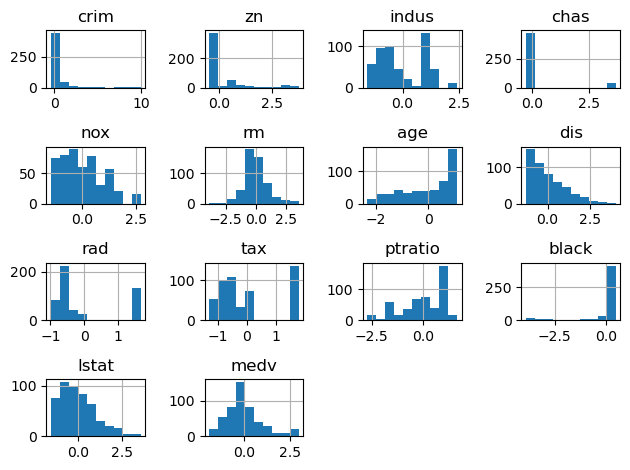

In [ ]:
df_standard.hist()
plt.tight_layout()
plt.show()

Since standardization works on data that is roughly Gaussian, we can see there is not much change compared to the original histograms. The histograms that improved slightly are:
1. rm
2. medv.

The others did not see any change compared to the original. That suggests other methods may work better for them, such as:
1. age
2. black
3. lstat
4. crim

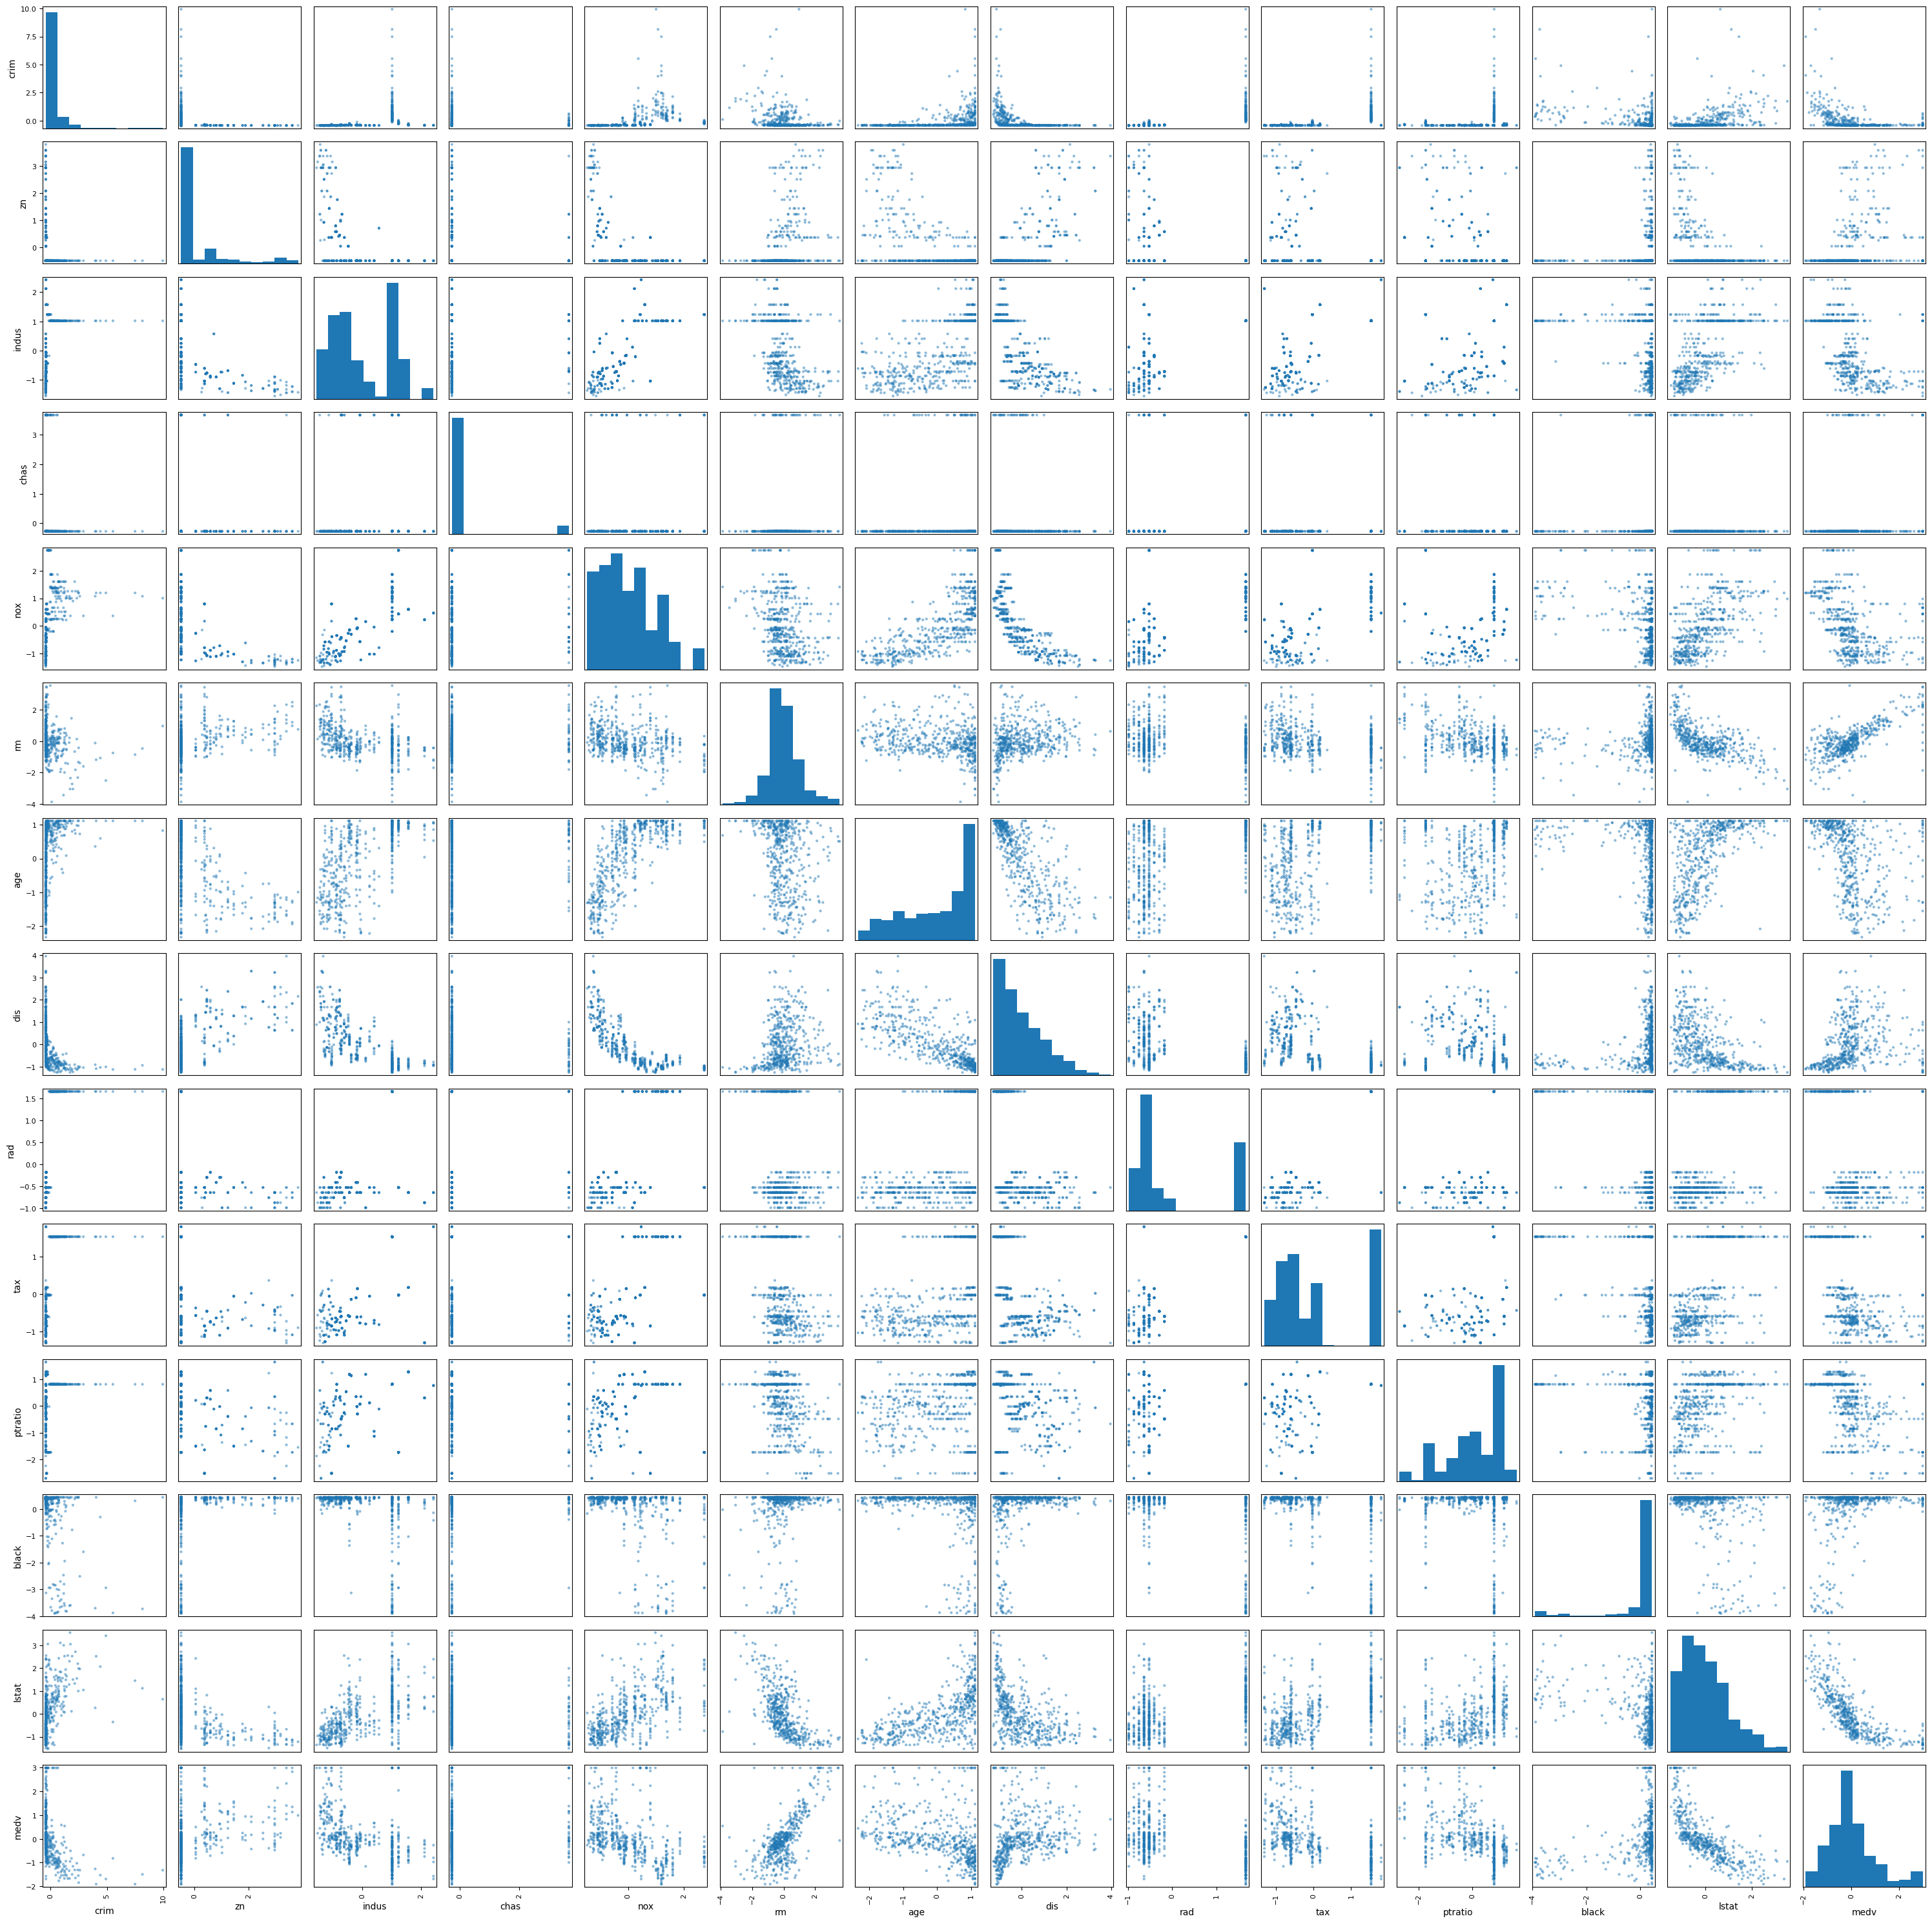

In [ ]:
scatter_matrix(df_standard, figsize=(30, 30))
plt.tight_layout()
plt.show()

Using this scatter plot of the standardized data, we see the input variables that are most strongly correlated are:
1. nox
2. rm
3. tax
4. ptratio
5. lstat.

We can see the list here is similar to the original data.

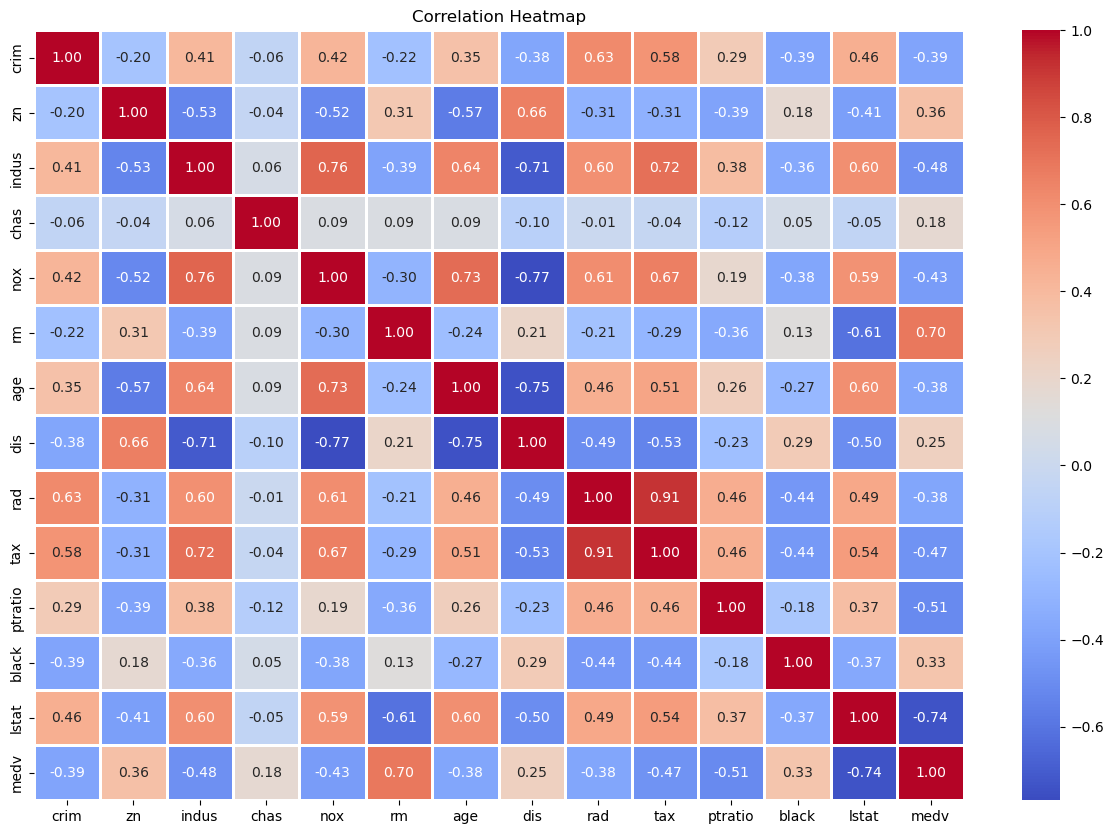

In [ ]:
plt.figure(figsize=(15, 10))

sns.heatmap(df_standard.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=2)

plt.title('Correlation Heatmap')
plt.show()

The five input values with the strongest correlation after standardization are:
1. lstat
2. rm
3. ptratio
4. indus
5. tax.

When we compare this list to the original data, we can see it is exactly the same.

In [ ]:
array = df_standard.values
# print(array)
X = array[:,0:13]
Y = array[:,13]
# print(X)
# print(Y)

NUM_FEATURES = 13 # this is kind of arbitrary but the idea should come by observing the scatter plots and correlation.
model = LinearRegression()
for i in range(NUM_FEATURES, 0, -1):
    print(i)
    rfe = RFE(model, n_features_to_select=i)
    fit = rfe.fit(X, Y)
    print("Num Features:", fit.n_features_)
    print("Selected Features:", fit.support_)
    print("Feature Ranking:", fit.ranking_)
    # calculate the score for the selected features
    score = rfe.score(X,Y)
    print("Model Score with selected features is: ", score)
    print()

13
Num Features: 13
Selected Features: [ True  True  True  True  True  True  True  True  True  True  True  True
  True]
Feature Ranking: [1 1 1 1 1 1 1 1 1 1 1 1 1]
Model Score with selected features is:  0.7406426641094093

12
Num Features: 12
Selected Features: [ True  True  True  True  True  True False  True  True  True  True  True
  True]
Feature Ranking: [1 1 1 1 1 1 2 1 1 1 1 1 1]
Model Score with selected features is:  0.7406412165505143

11
Num Features: 11
Selected Features: [ True  True False  True  True  True False  True  True  True  True  True
  True]
Feature Ranking: [1 1 2 1 1 1 3 1 1 1 1 1 1]
Model Score with selected features is:  0.7405822802569574

10
Num Features: 10
Selected Features: [ True  True False False  True  True False  True  True  True  True  True
  True]
Feature Ranking: [1 1 3 2 1 1 4 1 1 1 1 1 1]
Model Score with selected features is:  0.7352631473231817

9
Num Features: 9
Selected Features: [ True  True False False  True  True False  True  True  True  T

Using RFE on standardized data, we can see that the number of features we need is smaller than the original data. In fact, this RFE is saying we should use 5 features, as opposed to 6 from the original data. The input variables recommended here are:
1. nox
2. rm
3. dis
4. ptratio
5. lstat.

The only variable the standardized RFE excluded was chas. The five listed here also appeared in the RFE for the original data.

In [ ]:
X2 = df_standard.drop(df_standard.columns[13], axis = 1)
Y2 = df_standard.drop(df_standard.columns[0:13], axis = 1)

result = stepwise_selection(X2, Y2)
print('resulting features:')
print(result)

Add                               3 with p-value 5.0811e-88
Add                              10 with p-value 3.47226e-27
Add                               8 with p-value 1.64466e-14
Add                               0 with p-value 1.66847e-05
Add                               4 with p-value 5.48815e-08
Add                               2 with p-value 0.000265473
Add                               5 with p-value 0.000771946
Add                               3 with p-value 0.00465162
resulting features:
['lstat', 'rm', 'ptratio', 'dis', 'nox', 'chas', 'black', 'zn']


For the standardized stepwise, the features listed are the exact same as the listed features the original stepwise recommended. Overall, there is no change between them.

## Normalization

In [ ]:
scaler = Normalizer().fit(df)
normalized = scaler.transform(df)
df_normalized = pd.DataFrame(normalized, columns=names)

In [ ]:
df_normalized.head().round(3)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.0,0.036,0.005,0.0,0.001,0.013,0.130,0.008,0.002,0.591,0.031,0.793,0.010,0.048
1,0.0,0.000,0.015,0.0,0.001,0.014,0.167,0.011,0.004,0.512,0.038,0.840,0.019,0.046
2,0.0,0.000,0.015,0.0,0.001,0.015,0.131,0.011,0.004,0.518,0.038,0.841,0.009,0.074
3,0.0,0.000,0.005,0.0,0.001,0.015,0.100,0.013,0.007,0.486,0.041,0.864,0.006,0.073
4,0.0,0.000,0.005,0.0,0.001,0.016,0.118,0.013,0.007,0.483,0.041,0.863,0.012,0.079


In [ ]:
df_normalized.describe().round(3)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000
mean,0.005,0.023,0.019,0.000,0.001,0.012,0.121,0.007,0.015,0.690,0.033,0.657,0.022,0.042
std,0.012,0.047,0.011,0.000,0.000,0.003,0.048,0.005,0.011,0.152,0.006,0.210,0.011,0.021
min,0.000,0.000,0.001,0.000,0.001,0.005,0.006,0.001,0.002,0.425,0.024,0.000,0.003,0.006
25%,0.000,0.000,0.011,0.000,0.001,0.009,0.086,0.003,0.008,0.574,0.027,0.507,0.014,0.028
50%,0.000,0.000,0.017,0.000,0.001,0.012,0.126,0.006,0.010,0.652,0.033,0.744,0.020,0.040
75%,0.005,0.025,0.024,0.000,0.001,0.013,0.156,0.011,0.031,0.851,0.038,0.804,0.028,0.051
max,0.113,0.207,0.061,0.002,0.002,0.018,0.237,0.028,0.036,0.993,0.053,0.888,0.070,0.113


We are showing the descriptive statistics of the normalized data. Just like the standardized data above, we want to observe the descriptive statistics because we want to compare it to the original too and see what input features we can select to build our model.

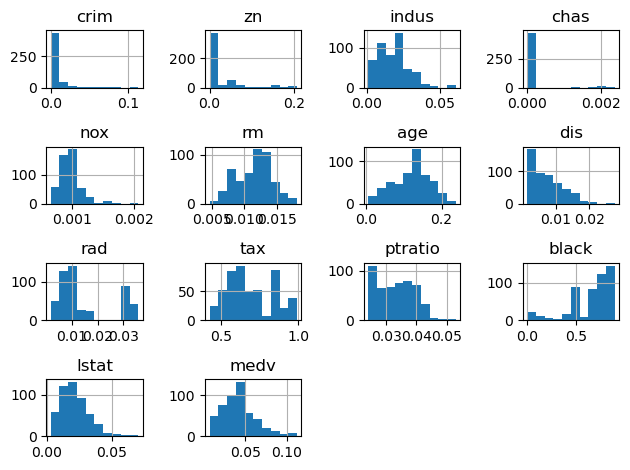

In [ ]:
df_normalized.hist()
plt.tight_layout()
plt.show()

After normalization, we can see the histograms for
1. age
2. rm
3. black
4. tax

seemed to have improve.

However, some did not see improvement or have gotten worse. The ones that did not see improvement are:
1. crim
2. zn
3. chas
4. dis
5. lstat

The ones that seemed to get worse are:
1. ptratio
2. medv

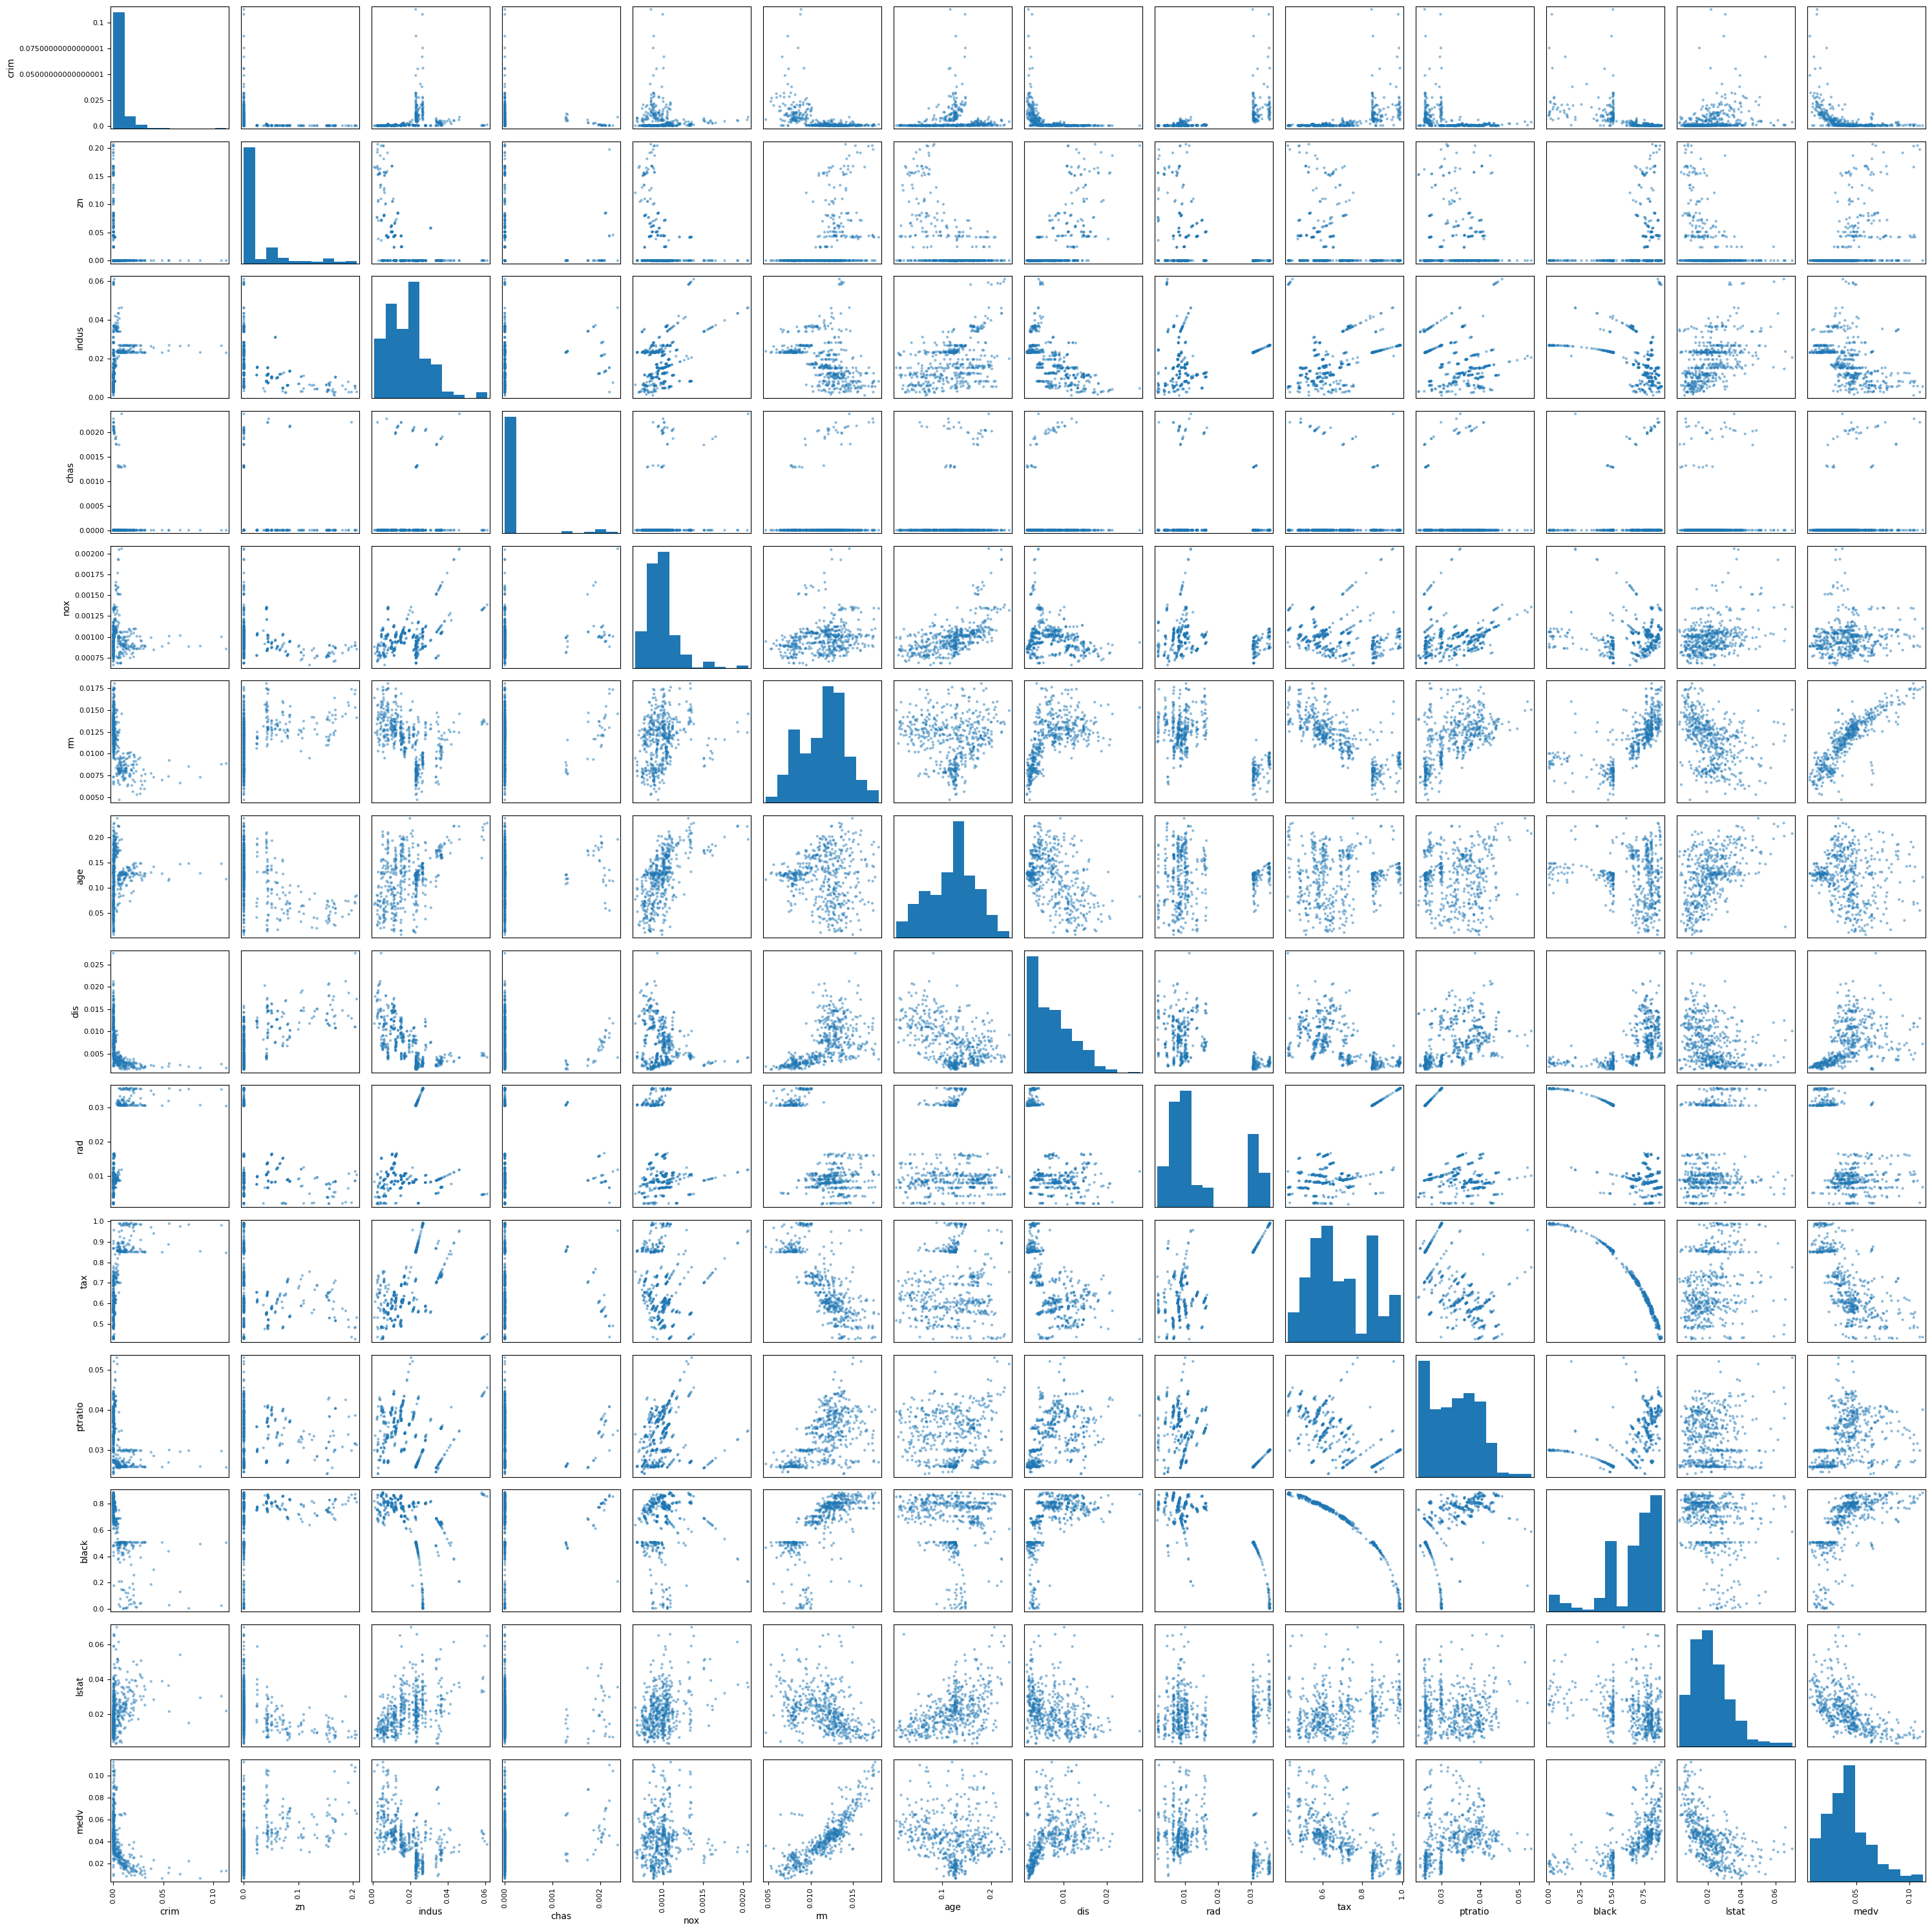

In [ ]:
scatter_matrix(df_normalized, figsize=(30, 30))
plt.tight_layout()
plt.show()

Using the normalized data, the input features that seem to have the strongest correlation to medv are:
1. rm
2. dis
3. tax
4. black
5. lstat

We can see that when we compare this list to the original data, the input features that appear on both are:
1. rm
2. lstat
3. tax.

However the new changes are
1. dis
2. black

The removed original values are
1. nox
2. ptratio

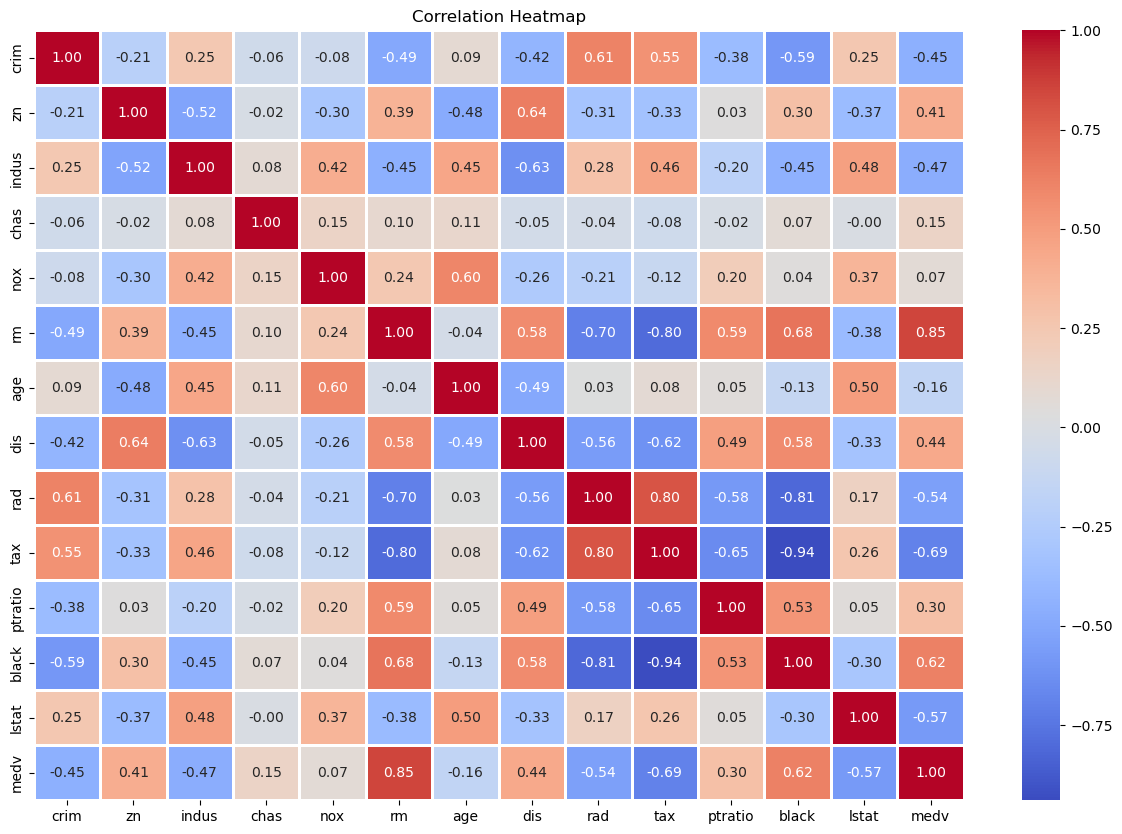

In [ ]:
plt.figure(figsize=(15, 10))

sns.heatmap(df_normalized.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=2)

plt.title('Correlation Heatmap')
plt.show()

Using the heat map above, the strongest correlation to medv using the normalized data are
1. rm
2. tax
3. black
4. lstat
5. rad

The difference between the original and the normalized are
1. black replaces ptratio
2. rad replaces indus.

In [ ]:
array = df_normalized.values
# print(array)
X = array[:,0:13]
Y = array[:,13]
# print(X)
# print(Y)

NUM_FEATURES = 13 # this is kind of arbitrary but the idea should come by observing the scatter plots and correlation.
model = LinearRegression()
for i in range(NUM_FEATURES, 0, -1):
    print(i)
    rfe = RFE(model, n_features_to_select=i)
    fit = rfe.fit(X, Y)
    print("Num Features:", fit.n_features_)
    print("Selected Features:", fit.support_)
    print("Feature Ranking:", fit.ranking_)
    # calculate the score for the selected features
    score = rfe.score(X,Y)
    print("Model Score with selected features is: ", score)
    print()

13
Num Features: 13
Selected Features: [ True  True  True  True  True  True  True  True  True  True  True  True
  True]
Feature Ranking: [1 1 1 1 1 1 1 1 1 1 1 1 1]
Model Score with selected features is:  0.8558160289425538

12
Num Features: 12
Selected Features: [ True  True  True  True  True  True  True  True  True  True  True False
  True]
Feature Ranking: [1 1 1 1 1 1 1 1 1 1 1 2 1]
Model Score with selected features is:  0.8557333332747975

11
Num Features: 11
Selected Features: [ True  True False  True  True  True  True  True  True  True  True False
  True]
Feature Ranking: [1 1 2 1 1 1 1 1 1 1 1 3 1]
Model Score with selected features is:  0.8557213604037688

10
Num Features: 10
Selected Features: [ True  True False  True  True  True False  True  True  True  True False
  True]
Feature Ranking: [1 1 3 1 1 1 2 1 1 1 1 4 1]
Model Score with selected features is:  0.8542832803868444

9
Num Features: 9
Selected Features: [ True False False  True  True  True False  True  True  True  T

The RFE on normalized data recommend the features to use are:
1. chas,
2. nox,
3. rm,
4. dis,
5. ptratio

The original RFE recommended 6 features, and the features the normalized RFE replaced or removed is only lstat. Everything else is the same.

In [ ]:
X3 = df_normalized.drop(df_normalized.columns[13], axis = 1)
Y3 = df_normalized.drop(df_normalized.columns[0:13], axis = 1)

result = stepwise_selection(X3, Y3)
print('resulting features:')
print(result)

Add                              11 with p-value 5.43491e-144
Add                               3 with p-value 1.15304e-34
Add                               8 with p-value 2.14339e-17
Add                               2 with p-value 5.96184e-09
Add                               0 with p-value 2.34807e-07
Add                               5 with p-value 0.00135092
resulting features:
['rm', 'lstat', 'ptratio', 'tax', 'dis', 'age']


Stepwise on the normalized data recommend
1. rm
2. lstat
3. ptratio
4. tax
5. dis
6. age

The normalized stepwise replaced or removed these variables:
1. nox --> tax
2. black --> age
3. zn (removed)

## Some final remarks

Using RFE and stepwise on the original data, standardized data, and normalized data, we can see that normalization had greater impact in feature selection than standardization. The original RFE and stepwise features respectively are:
1. chas
2. nox
3. rm
4. dis
5. ptratio
6. lstat

and
1. lstat
2. rm
3. ptratio
4. dis
5. nox
6. chas
7. black
8. zn.

For standardization, they are
1. nox
2. rm
3. dis
4. ptratio
5. lstat

and
1. lstat
2. rm
3. ptratio
4. dis
5. nox
6. chas
7. black
8. zn.

For normalization,
1. chas,
2. nox,
3. rm,
4. dis,
5. ptratio

and
1. rm
2. lstat
3. ptratio
4. tax
5. dis
6. age.

We see there was a greater change with normalization because when we compare the RFE and stepwise between them, we see for RFE, the only input value that was not included after standardization was chas. The stepwise for both chose the exact same features. This means standardization only had minimal impact on feature selection.

Normalization, however, had a greater impact. The reasons why normalization had a greater impact than standardization could be
1. some features were more important than realized and normalization was able to reveal that
2. normalization was able to balance the feature influence more than standardization
3. reduce the dominance of certain features
4. can be heavily influenced by outliers
5. compresses all features within the range of [0, 1] which can impact feature selection more.

Overall, these reasons could explain why we saw a greater feature selection change than standardization compared to the original data.

But it is important to realize that does not mean normalization is better, so to test what method works better depends on the model's prediction such as
1. R-square
2. MSE
3. generalization to new data

If it ends up standardization improves model prediction more than normalization, we should only use standardization.